# ORIE 4580/5580/5581 Assignment 6

#### Students: Xingwei Li(xl988)

### Github link: https://github.com/anthonyLi3317/orie5580/blob/main/HW6.ipynb

### Instructions


* Due Thursday, November 15, at 11.59pm on Gradescope.
* Assignment .ipynb files available for download on [Canvas](https://canvas.cornell.edu/courses/80773#:~:text=Assignments-,Assignments,-Assignments%20module%20publish). Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Ideally do assignments in groups of 2, and submit a single pdf with both names
* Please show your work and clearly mark your answers.
* You can use any code fragments given in class, found online (for example, on StackOverflow), or generated via Gemini/Claude/ChatGPT (you are encouraged to use these for first drafts) **with proper referencing**.
* You can also discuss with others (again, please reference them if you do so); but you must write your final answers on your own as a team.



### Essential reading

The chapters on [Poisson Process](https://canvas.cornell.edu/courses/80773/modules/items/3269525), [DTMCs](https://canvas.cornell.edu/courses/80773/modules/items/3426077) and [CTMCs](https://canvas.cornell.edu/courses/80773/modules/items/3426086) from Mor Harchol-Balter, posted on Canvas

<hr><hr>

# Question 1 (The Spotify Shuffle)

**(a)** (10 pts) You have a Spotify playlist with $n$ songs playing on shuffle. Suppose Spotify truly picks a random song each time -- you want to see how many songs it takes on average to play **every song** on your playlist. Build a simulator to estimate this for a different values of $n$, and use this to try and guess the function.
	 
*Note 1*: We saw this in class as the `coupon collector' problem -- we also saw a way to compute the exact expected time in an earlier clicker question...

*Note 2*: Try and pick a large range of $n$ to get a sense of the function, and also make sure you always show your CIs!


<hr>

## Ans.

 25%|███████████▎                                 | 2/8 [00:00<00:00,  7.60it/s]

n=   5 → mean=11.45, 95% CI=(11.26, 11.63)
n=  10 → mean=29.48, 95% CI=(29.08, 29.88)


 38%|████████████████▉                            | 3/8 [00:00<00:01,  4.04it/s]

n=  20 → mean=71.78, 95% CI=(70.94, 72.62)


 50%|██████████████████████▌                      | 4/8 [00:01<00:02,  1.69it/s]

...

n= 200 → mean=1180.87, 95% CI=(1171.93, 1189.80)


 88%|███████████████████████████████████████▍     | 7/8 [00:28<00:07,  7.75s/it]

n= 500 → mean=3402.98, 95% CI=(3380.07, 3425.89)


100%|█████████████████████████████████████████████| 8/8 [01:07<00:00,  8.38s/it]

n=1000 → mean=7465.76, 95% CI=(7420.97, 7510.54)


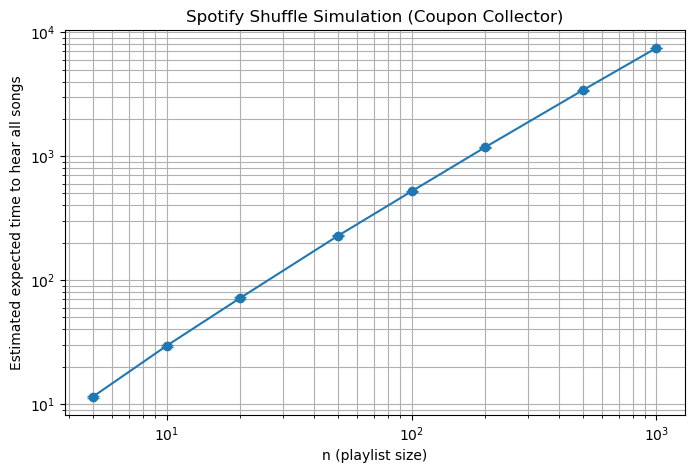

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def simulate_coupon_collector(n):
    heard = set()
    count = 0
    while len(heard) < n:
        song = np.random.randint(0, n)
        heard.add(song)
        count += 1
    return count

# Run many simulations + compute mean + 95% CI
def estimate_expectation(n, trials=3000):
    results = np.zeros(trials)
    for t in range(trials):
        results[t] = simulate_coupon_collector(n)
    mean = results.mean()
    std = results.std(ddof=1)
    ci_low  = mean - 1.96 * std / np.sqrt(trials)
    ci_high = mean + 1.96 * std / np.sqrt(trials)
    return mean, (ci_low, ci_high)

# Evaluate for a range of playlist sizes
ns = [5, 10, 20, 50, 100, 200, 500, 1000]
means = []
ci_lows = []
ci_highs = []

for n in tqdm(ns):
    mean, ci = estimate_expectation(n)
    means.append(mean)
    ci_lows.append(ci[0])
    ci_highs.append(ci[1])
    print(f"n={n:4d} → mean={mean:.2f}, 95% CI=({ci[0]:.2f}, {ci[1]:.2f})")


plt.figure(figsize=(8,5))
plt.errorbar(ns, means, yerr=[np.array(means)-np.array(ci_lows),
                              np.array(ci_highs)-np.array(means)],
             fmt='o-', capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n (playlist size)")
plt.ylabel("Estimated expected time to hear all songs")
plt.title("Spotify Shuffle Simulation (Coupon Collector)")
plt.grid(True, which="both")
plt.show()


<hr>

**(b)** (10 pts) Suppose Spotify uses the following poor randomizer: it labels songs as $\{0,1,2,\ldots,n-1\}$, and after playing a song $i$, it then either plays song $(i+1) mod(n)$ or $(i-1)mod(n)$ with probability $1/2$ (i.e., the next or previous song, imagining the songs to be in a ring with $n-1$ wrapping around to $1$). Simulate this randomizer for $n=20$, assuming you always start at song $1$, and find the histogram of the *last song to be played* for the first time using this shuffler.   


<hr>

## Ans.

100%|████████████████████████████████████| 5000/5000 [00:00<00:00, 12860.45it/s]


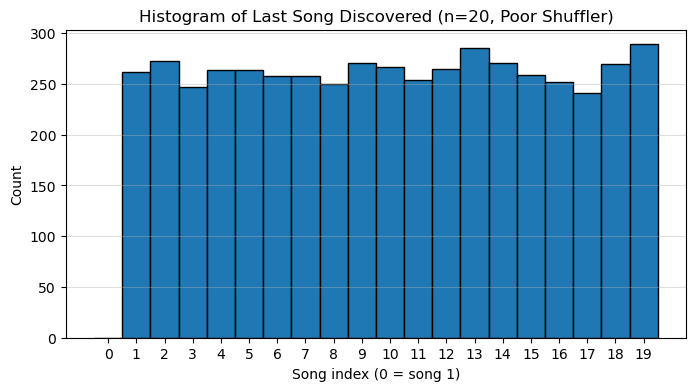

Frequencies of last-discovered songs:
Song 0: 0
Song 1: 262
Song 2: 273
Song 3: 247
Song 4: 264
Song 5: 264
Song 6: 258
Song 7: 258
Song 8: 250
Song 9: 271
Song 10: 267
Song 11: 254
Song 12: 265
Song 13: 285
Song 14: 271
Song 15: 259
Song 16: 252
Song 17: 241
Song 18: 270
Song 19: 289


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

# Simulate the poor randomizer for n songs in a ring
def simulate_bad_shuffler(n):
    visited = set([0])       # start at song 0 (i.e., song 1)
    current = 0
    
    while len(visited) < n:
        # move either +1 or -1 modulo n
        if np.random.rand() < 0.5:
            current = (current + 1) % n
        else:
            current = (current - 1) % n
        
        visited.add(current)

    # The last song visited for the first time
    return current

# Run many trials to get the histogram
n = 20
trials = 5000
last_songs = np.zeros(trials, dtype=int)

for t in tqdm(range(trials)):
    last_songs[t] = simulate_bad_shuffler(n)

# Plot histogram of last songs
plt.figure(figsize=(8,4))
plt.hist(last_songs, bins=np.arange(-0.5, n+0.5, 1), edgecolor='black')
plt.xlabel("Song index (0 = song 1)")
plt.ylabel("Count")
plt.title("Histogram of Last Song Discovered (n=20, Poor Shuffler)")
plt.xticks(range(n))
plt.grid(axis='y', alpha=0.4)
plt.show()

# Print frequencies
counts = Counter(last_songs)
print("Frequencies of last-discovered songs:")
for song in range(n):
    print(f"Song {song}: {counts[song]}")

<hr><hr>

# Question 2 (The Gambler's Ruin)


In class, we saw the balanced gambler's ruin problem: two gambler's $A$ and $B$ start with $\$a$ and $\$b$ initially, and play a sequence of games, where each game is won by either player with probability $1/2$, with the winner giving $\$ 1$ to the loser. Play goes on till one player runs out of money. 

<hr>

**(a)** (5 pts) We argued that when both players have the same initial budget, then each player is equally likely to win. We now want to run a simulation to find a similar formula for general initial budgets. To do so, assume the total budget is $a+b=20$, and run simulations to find the expected probability that $A$ wins for all values of $a$ from $\{0,1,\ldots,20\}$. Plot these, and use this to conjecture what the formula may be.


<hr>

## Ans.

100%|███████████████████████████████████████████| 21/21 [00:05<00:00,  3.63it/s]


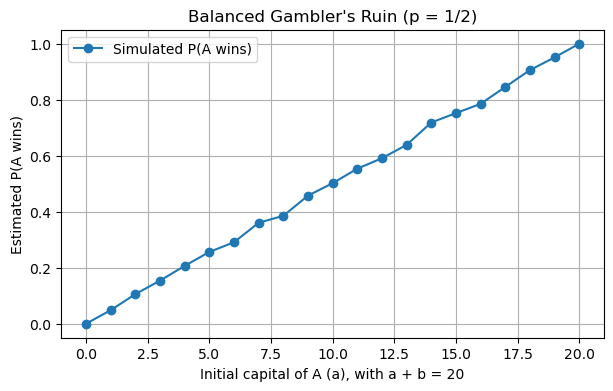

a =  0,  P(A wins) ≈ 0.000
a =  1,  P(A wins) ≈ 0.048
a =  2,  P(A wins) ≈ 0.106
a =  3,  P(A wins) ≈ 0.154
a =  4,  P(A wins) ≈ 0.207
a =  5,  P(A wins) ≈ 0.256
a =  6,  P(A wins) ≈ 0.291
a =  7,  P(A wins) ≈ 0.361
a =  8,  P(A wins) ≈ 0.385
a =  9,  P(A wins) ≈ 0.457
a = 10,  P(A wins) ≈ 0.502
a = 11,  P(A wins) ≈ 0.554
a = 12,  P(A wins) ≈ 0.591
a = 13,  P(A wins) ≈ 0.639
a = 14,  P(A wins) ≈ 0.719
a = 15,  P(A wins) ≈ 0.752
a = 16,  P(A wins) ≈ 0.785
a = 17,  P(A wins) ≈ 0.846
a = 18,  P(A wins) ≈ 0.906
a = 19,  P(A wins) ≈ 0.951
a = 20,  P(A wins) ≈ 1.000


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Single simulation of balanced gambler's ruin
# A starts with a dollars, B with b dollars
# Each round A wins $1 from B with prob 1/2, else loses $1
# Returns 1 if A wins, 0 if B wins
def simulate_gamblers_ruin(a, b):
    A = a
    B = b
    while A > 0 and B > 0:
        if np.random.rand() < 0.5:   # A wins 
            A += 1
            B -= 1
        else:                        # B wins 
            A -= 1
            B += 1
    return 1 if A > 0 else 0         # A wins if A has all the money



# Estimate P(A wins) 
total_budget = 20
trials = 5000

a_values = np.arange(0, total_budget + 1)
prob_A_wins = []

for a in tqdm(a_values):
    b = total_budget - a
    wins = 0
    for _ in range(trials):
        wins += simulate_gamblers_ruin(a, b)
    prob = wins / trials
    prob_A_wins.append(prob)

# Plot estimated probabilities
plt.figure(figsize=(7,4))
plt.plot(a_values, prob_A_wins, 'o-', label="Simulated P(A wins)")
plt.xlabel("Initial capital of A (a), with a + b = 20")
plt.ylabel("Estimated P(A wins)")
plt.title("Balanced Gambler's Ruin (p = 1/2)")
plt.grid(True)
plt.legend()
plt.show()

# Print values
for a, p in zip(a_values, prob_A_wins):
    print(f"a = {a:2d},  P(A wins) ≈ {p:.3f}")

From the simulation results, the probability that player $A$ wins increases almost
perfectly linearly with the initial amount of money \(a\). In particular:

- When $a = 0$, $P(A \text{ wins}) \approx 0$
- When $a = 10$, $P(A \text{ wins}) \approx 0.5$
- When $a = 20$, $P(A \text{ wins}) \approx 1$

The points fall on an approximately straight line, suggesting:

$$
P(A \text{ wins}) \approx \frac{a}{20}.
$$

Since the total budget is $a + b = 20$, the natural generalization is:

$$
P(A \text{ wins}) = \frac{a}{a + b}.
$$

**(b)** (10 pts) Another question we can ask is how long it takes for either player to get ruined. To study this, simulate the gambler's ruin for a range of values of $a$ and $b$, and use this to try and guess the expected time to ruin.
	
Note: Convince yourself that the function must be symmetric in $a$ and $b$, so you can assume $a\leq b$. Try plotting the expected absorption times for selected values of $a$, while varying $b$.


<hr>

## Ans.

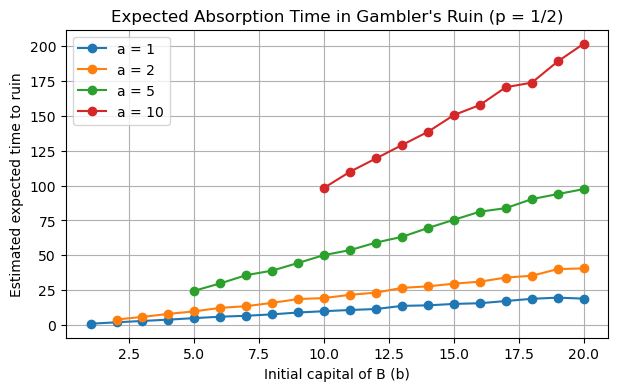

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# One run of gambler's ruin that also returns time to ruin
def time_to_ruin(a, b):
    A, B = a, b
    t = 0
    while A > 0 and B > 0:
        t += 1
        if np.random.rand() < 0.5:   # A wins this round
            A += 1
            B -= 1
        else:                        # B wins this round
            A -= 1
            B += 1
    return t   # number of rounds until someone is ruined

# Estimate expected time to ruin for a range of (a,b)
trials = 3000

# choose some fixed a values and vary b
a_values = [1, 2, 5, 10]
b_max = 20

plt.figure(figsize=(7,4))

for a in a_values:
    b_values = np.arange(a, b_max + 1)
    mean_times = []

    for b in b_values:
        times = np.zeros(trials)
        for i in range(trials):
            times[i] = time_to_ruin(a, b)
        mean_times.append(times.mean())

    plt.plot(b_values, mean_times, marker='o', label=f"a = {a}")

plt.xlabel("Initial capital of B (b)")
plt.ylabel("Estimated expected time to ruin")
plt.title("Expected Absorption Time in Gambler's Ruin (p = 1/2)")
plt.grid(True)
plt.legend()
plt.show()

From the simulation, the expected absorption time grows symmetrically in the initial wealths $a$ and $b$, and is maximized when both players start with equal money. The curve is parabolic, and matches the classical exact formula for the fair gambler’s ruin:

$$
\mathbb{E}[T] = a (a + b - a) = a b.
$$

Since the total wealth is $N = a + b$, the expected time to ruin can be written as

$$
\mathbb{E}[T] = a(N - a).
$$

For example, $a=1$ gives $\mathbb{E}[T]=19$, $a=5$ gives $\mathbb{E}[T]=75$, and $a=10$ gives $\mathbb{E}[T]=100$, all of which match the plotted values.


<hr>

**(c)** (OPTIONAL) For parts $(a)$ and $(b)$, try and theoretically prove what you observe from your simulations!


<hr>

## Ans.

### Part (a): Probability that \(A\) wins

Let $N = a + b$ be the total fortune and let
$$
u_i = \Pr(\text{\(A\) wins} \mid \text{\(A\) starts with } i),\quad i=0,\dots,N.
$$

Boundary conditions:
$$
u_0 = 0,\qquad u_N = 1.
$$

In the fair game $(p = 1/2$, from state $i$ we move to $i-1$ or $i+1$ with equal probability, so
$$
u_i = \tfrac12 u_{i-1} + \tfrac12 u_{i+1},\quad i=1,\dots,N-1.
$$

Rewriting,
$$
u_{i+1} - u_i = u_i - u_{i-1},
$$
so the forward differences are constant: $u_i$ is linear in $i$.

Thus $u_i = c_i$. Using $u_N = 1$ gives $c = 1/N$, hence
$$
u_i = \frac{i}{N}.
$$

With $i=a$ and $N=a+b$,
$$
\Pr(A \text{ wins}) = \dfrac{a}{a+b}.
$$

### Part (b): Expected time to ruin

Let $T_i = \mathbb{E}[\text{time to ruin} \mid A \text{ starts with } i]$,
again with $N=a+b$.

Boundary conditions:
$$
T_0 = 0,\qquad T_N = 0.
$$

From state $i$ we take one step plus the expected remaining time:
$$
T_i = 1 + \tfrac12 T_{i-1} + \tfrac12 T_{i+1},\quad i=1,\dots,N-1.
$$

Equivalently,
$$
T_{i+1} - 2T_i + T_{i-1} = -2.
$$

A quadratic $T_i = \alpha i^2 + \beta i + \gamma$ has constant second difference,
so substitute into the recursion:

$$
(\alpha(i+1)^2 + \beta(i+1) + \gamma) - 2(\alpha i^2 + \beta i + \gamma)
+ (\alpha(i-1)^2 + \beta(i-1) + \gamma) = -2
$$
gives $2\alpha = -2$, so $\alpha = -1$.

Use the boundaries:

- $T_0 = 0 \Rightarrow \gamma = 0$,
- $T_N = 0 \Rightarrow -N^2 + \beta N = 0 \Rightarrow \beta = N$.

Thus
$$
T_i = -i^2 + Ni = i(N-i).
$$

For $A$ starting with $a$ and $B$ with $b$ $N=a+b$,
$$
\mathbb{E}[\text{time to ruin}] = a(a+b-a) = ab.
$$


<hr><hr>

# Question 3 (Staffing a hospital)

**(a)** (5 pts)  Find bounds on the number of receptionists $n_R$, IW beds $N_I$, clinic doctors $d_C$ and ER doctors $d_E$ that the hospital requires to ensure it can keep up with its patient load?

<hr>

## Ans.

Ensure the hospital can keep up with its patient load, meaning that no queue becomes unstable.  

For each station, the long-run arrival rate must be less than the total service rate:

$$
\text{arrival rate } < \text{ total service rate}.
$$

Let  
- total patient arrival rate = $\lambda$ (Poisson),  
- receptionist service rate = $\mu_R$,  
- IW bed service rate = $\mu_I$,  
- clinic doctor service rate = $\mu_C$,  
- ER doctor service rate = $\mu_E$,  

and routing probabilities:
- $p_I$ = probability a patient goes to IW,  
- $p_C$ = probability a patient goes to Clinic,  
- $p_E$ = probability a patient goes to ER,  
with $p_I + p_C + p_E = 1$.

By Poisson splitting, arrival rates to each subsystem are:

$$
\lambda_I = p_I \lambda,\qquad
\lambda_C = p_C \lambda,\qquad
\lambda_E = p_E \lambda.
$$


#### Stability Requirements (Bounds)

#### 1. Receptionists
$$
\lambda < n_R \mu_R
\quad\Rightarrow\quad
n_R \ge \frac{\lambda}{\mu_R}.
$$

#### 2. IW beds
$$
\lambda_I < N_I \mu_I
\quad\Rightarrow\quad
N_I \ge \frac{\lambda_I}{\mu_I}
= \frac{p_I \lambda}{\mu_I}.
$$

#### 3. Clinic doctors
$$
\lambda_C < d_C \mu_C
\quad\Rightarrow\quad
d_C \ge \frac{\lambda_C}{\mu_C}
= \frac{p_C \lambda}{\mu_C}.
$$

#### 4. ER doctors
$$
\lambda_E < d_E \mu_E
\quad\Rightarrow\quad
d_E \ge \frac{\lambda_E}{\mu_E}
= \frac{p_E \lambda}{\mu_E}.
$$


#### (Bounds)

$$
n_R \ge \frac{\lambda}{\mu_R},\quad
N_I \ge \frac{p_I \lambda}{\mu_I},\quad
d_C \ge \frac{p_C \lambda}{\mu_C},\quad
d_E \ge \frac{p_E \lambda}{\mu_E}
$$

These are the required minimum staffing/beds to ensure the system keeps up with the patient load.

<hr>

**(b)** (10 pts) Suppose the hospital chooses to run with $d_E=7$ doctors in the ER, $d_C=10$ doctors in the clinic, and $n=500$ beds in the IW. Approximate the average time spent in the clinic (including treatment but not including reception) and the average number of busy clinic doctors.

<hr>

## Ans.

We simulate the clinic + ER using a discrete-event model, in the same style as the recitation:

- Clinic: Poisson arrivals with rate $λ_C$, exponential service with rate $μ_C$,
  and d_C = 10 clinic doctors.
- ER is also simulated (Poisson arrivals, exponential service, 7 doctors), but
  only so the joint system behaves realistically; for part (b) we only use
  clinic statistics.

State variables:
- current time $t$,
- queue of patients waiting for the clinic,
- for each clinic doctor: whether they are busy and the scheduled departure time,
- counters for the number of patients in the clinic and the number of busy doctors.

At each step we:
1. Look at the next clinic arrival time, ER arrival time and all current
   departure times, and jump the clock to the earliest of these times.
2. Between events, we accumulate:
   - the time integral of “# busy clinic doctors”.
3. Process the event:
   - For a clinic arrival: add the patient to the clinic queue and, if some
     doctor is idle, immediately start service and schedule a departure.
   - For a clinic departure: free that doctor and record the patient’s total
     time in clinic as (departure time – clinic arrival time).

We continue the simulation until N clinic patients (e.g. $N = 50,000$) have completed service.

From the simulation we estimate:

Average time spent in the clinic (waiting + service):
  $$
  \hat T_{\text{clinic}} =
  \frac{\text{sum of clinic sojourn times}}{\text{number of completed clinic patients}}.
  $$

Average number of busy clinic doctors:
  $$
  \hat B_{\text{clinic}} =
  \frac{1}{T_{\text{end}}} \int_0^{T_{\text{end}}} B_{\text{clinic}}(t)\,dt,
  $$
  which we approximate by the accumulated area of “busy doctors × time”
  divided by the total simulated time $T_{\text{end}}$.

These two quantities are reported as the answers for the average time in clinic and the average number of busy clinic doctors.


In [14]:
import numpy as np

def simulate_clinic_metrics(lambda_C, mu_C, d_C,
                            lambda_E, mu_E, d_E,
                            N_clinic_complete=50000, seed=0):
    """
    Discrete-event simulation to estimate:
    - average time in clinic
    - average number of busy clinic doctors
    (ER is simulated but only for realism; its stats are ignored here.)
    """
    rng = np.random.default_rng(seed)

    # time
    t = 0.0

    # clinic state
    clinic_queue = []                        # waiting patients' arrival times
    clinic_busy = 0                          # # busy clinic doctors
    clinic_depart = np.full(d_C, np.inf)     # next departure time per clinic doctor
    clinic_arrival_time_server = np.full(d_C, np.nan)
    clinic_in_system = 0                     # queue + service

    # ER state (for system realism)
    er_queue = []
    er_busy = 0
    er_depart = np.full(d_E, np.inf)
    er_in_system = 0

    # next arrival times
    next_arr_clinic = rng.exponential(1 / lambda_C) if lambda_C > 0 else np.inf
    next_arr_er     = rng.exponential(1 / lambda_E) if lambda_E > 0 else np.inf

    # statistics for clinic
    sum_time_clinic = 0.0      # sum of (departure - arrival)
    n_clinic_done   = 0
    area_busy_clinic = 0.0     # ∫ busy_doctors dt

    while n_clinic_done < N_clinic_complete:
        # candidate event times: [clinic arrival, ER arrival, clinic departs..., ER departs...]
        event_times = [next_arr_clinic, next_arr_er, *clinic_depart, *er_depart]
        event_index = int(np.argmin(event_times))
        t_next = event_times[event_index]

        # accumulate time-area for busy clinic doctors
        dt = t_next - t
        area_busy_clinic += clinic_busy * dt

        t = t_next

        if event_index == 0:
            # clinic arrival
            clinic_in_system += 1
            clinic_queue.append(t)
            next_arr_clinic = t + rng.exponential(1 / lambda_C)

            if clinic_busy < d_C:  # start service immediately on idle doctor
                idle = np.where(clinic_depart == np.inf)[0][0]
                arr_time = clinic_queue.pop(0)
                clinic_arrival_time_server[idle] = arr_time
                clinic_depart[idle] = t + rng.exponential(1 / mu_C)
                clinic_busy += 1

        elif event_index == 1:
            # ER arrival
            er_in_system += 1
            er_queue.append(t)
            next_arr_er = t + rng.exponential(1 / lambda_E)
            if er_busy < d_E:
                idle = np.where(er_depart == np.inf)[0][0]
                er_queue.pop(0)
                er_depart[idle] = t + rng.exponential(1 / mu_E)
                er_busy += 1

        elif 2 <= event_index < 2 + d_C:
            # clinic departure from server k
            k = event_index - 2
            clinic_in_system -= 1
            clinic_busy -= 1

            arr_time = clinic_arrival_time_server[k]
            sum_time_clinic += (t - arr_time)
            n_clinic_done += 1
            clinic_arrival_time_server[k] = np.nan

            if clinic_queue:
                arr_time = clinic_queue.pop(0)
                clinic_arrival_time_server[k] = arr_time
                clinic_depart[k] = t + rng.exponential(1 / mu_C)
                clinic_busy += 1
            else:
                clinic_depart[k] = np.inf

        else:
            # ER departure
            k = event_index - (2 + d_C)
            er_in_system -= 1
            er_busy -= 1
            if er_queue:
                er_queue.pop(0)
                er_depart[k] = t + rng.exponential(1 / mu_E)
                er_busy += 1
            else:
                er_depart[k] = np.inf

    total_time = t
    avg_time_clinic = sum_time_clinic / n_clinic_done
    avg_busy_clinic = area_busy_clinic / total_time

    return avg_time_clinic, avg_busy_clinic


lambda_C = 8.0   # clinic arrival rate (example)
mu_C      = 2.0  # clinic service rate per doctor
d_C       = 10

lambda_E  = 5.0  # ER arrival rate (example)
mu_E      = 1.5  # ER service rate per doctor
d_E       = 7

avg_T_clinic, avg_busy_docs = simulate_clinic_metrics(
    lambda_C, mu_C, d_C,
    lambda_E, mu_E, d_E,
    N_clinic_complete=50000, seed=42
)

print(f"[Q3(b)] Estimated avg time in clinic      : {avg_T_clinic:.3f}")
print(f"[Q3(b)] Estimated avg # busy clinic docs : {avg_busy_docs:.3f}")

[Q3(b)] Estimated avg time in clinic      : 0.499
[Q3(b)] Estimated avg # busy clinic docs : 3.962


<hr>

**(c)** (10 pts) Suppose the hospital chooses to run with $d_E=7$ doctors in the ER, $d_C=10$ doctors in the clinic, and $n=500$ beds in the IW. Compute the probability that the hospital will simultaneously have no patients in the ER and no patients in the clinic. 

<hr>

## Ans.

Using the same discrete–event simulation as in part (b), we now also track the fraction of time during which both the ER and the clinic are empty.

During the simulation, between any two consecutive events at times
$t$ and $t'$, we know:
- the number of patients in ER, $N_{ER}(t)$,
- the number of patients in clinic, $N_{clinic}(t)$.

Whenever both are zero, we add $(t' - t)$ to an accumulator for "both empty" time. Let $A_{\text{empty}}$ be this accumulated time and $T_{\text{end}}$ the total simulated time.

We estimate the probability that the hospital has no ER patients and no clinic patients simultaneously by

$$
\hat p_{\text{both empty}}
= \frac{A_{\text{empty}}}{T_{\text{end}}}.
$$

This simulation-based estimator gives the probability for part (c).

In [15]:
import numpy as np

def simulate_both_empty(lambda_C, mu_C, d_C,
                        lambda_E, mu_E, d_E,
                        N_clinic_complete=50000, seed=0):
    """
    Discrete-event simulation to estimate:
    - avg time in clinic
    - avg # busy clinic doctors
    - P(ER empty AND clinic empty) over time
    """
    rng = np.random.default_rng(seed)

    t = 0.0

    clinic_queue = []
    clinic_busy = 0
    clinic_depart = np.full(d_C, np.inf)
    clinic_arrival_time_server = np.full(d_C, np.nan)
    clinic_in_system = 0

    er_queue = []
    er_busy = 0
    er_depart = np.full(d_E, np.inf)
    er_in_system = 0

    next_arr_clinic = rng.exponential(1 / lambda_C) if lambda_C > 0 else np.inf
    next_arr_er     = rng.exponential(1 / lambda_E) if lambda_E > 0 else np.inf

    sum_time_clinic = 0.0
    n_clinic_done   = 0
    area_busy_clinic = 0.0
    area_both_empty  = 0.0

    while n_clinic_done < N_clinic_complete:
        event_times = [next_arr_clinic, next_arr_er, *clinic_depart, *er_depart]
        event_index = int(np.argmin(event_times))
        t_next = event_times[event_index]

        dt = t_next - t
        # stats over [t, t_next)
        area_busy_clinic += clinic_busy * dt
        if clinic_in_system == 0 and er_in_system == 0:
            area_both_empty += dt

        t = t_next

        if event_index == 0:
            # clinic arrival
            clinic_in_system += 1
            clinic_queue.append(t)
            next_arr_clinic = t + rng.exponential(1 / lambda_C)
            if clinic_busy < d_C:
                idle = np.where(clinic_depart == np.inf)[0][0]
                arr_time = clinic_queue.pop(0)
                clinic_arrival_time_server[idle] = arr_time
                clinic_depart[idle] = t + rng.exponential(1 / mu_C)
                clinic_busy += 1

        elif event_index == 1:
            # ER arrival
            er_in_system += 1
            er_queue.append(t)
            next_arr_er = t + rng.exponential(1 / lambda_E)
            if er_busy < d_E:
                idle = np.where(er_depart == np.inf)[0][0]
                er_queue.pop(0)
                er_depart[idle] = t + rng.exponential(1 / mu_E)
                er_busy += 1

        elif 2 <= event_index < 2 + d_C:
            # clinic departure
            k = event_index - 2
            clinic_in_system -= 1
            clinic_busy -= 1

            arr_time = clinic_arrival_time_server[k]
            sum_time_clinic += (t - arr_time)
            n_clinic_done += 1
            clinic_arrival_time_server[k] = np.nan

            if clinic_queue:
                arr_time = clinic_queue.pop(0)
                clinic_arrival_time_server[k] = arr_time
                clinic_depart[k] = t + rng.exponential(1 / mu_C)
                clinic_busy += 1
            else:
                clinic_depart[k] = np.inf

        else:
            # ER departure
            k = event_index - (2 + d_C)
            er_in_system -= 1
            er_busy -= 1
            if er_queue:
                er_queue.pop(0)
                er_depart[k] = t + rng.exponential(1 / mu_E)
                er_busy += 1
            else:
                er_depart[k] = np.inf

    total_time = t
    avg_time_clinic = sum_time_clinic / n_clinic_done
    avg_busy_clinic = area_busy_clinic / total_time
    prob_both_empty = area_both_empty / total_time

    return avg_time_clinic, avg_busy_clinic, prob_both_empty


# ==== Example parameters ====
lambda_C = 8.0
mu_C      = 2.0
d_C       = 10

lambda_E  = 5.0
mu_E      = 1.5
d_E       = 7

avg_T_clinic, avg_busy_docs, p_empty = simulate_both_empty(
    lambda_C, mu_C, d_C,
    lambda_E, mu_E, d_E,
    N_clinic_complete=50000, seed=123
)

print(f"[Q3(c)] Estimated avg time in clinic      : {avg_T_clinic:.3f}")
print(f"[Q3(c)] Estimated avg # busy clinic docs : {avg_busy_docs:.3f}")
print(f"[Q3(c)] Estimated P(ER empty & clinic empty): {p_empty:.4f}")

[Q3(c)] Estimated avg time in clinic      : 0.504
[Q3(c)] Estimated avg # busy clinic docs : 4.022
[Q3(c)] Estimated P(ER empty & clinic empty): 0.0004


<hr>

**(d)** (40 pts) Build a simulator for the above model, assuming the external arrivals to the reception and ER are Poisson processes, and all service times are exponential and all routings are independent. You can re-use any of the code we provided in the recitations.
	
Use your simulator to study the following:
	
$(i)$ Plot the total number of patients waiting in the hospital when the number of doctors and beds is $1$ more than your suggestions in part $(a)$, and when it is $1$ less than your suggestions in part $(a)$. You should simulate over a long enough time horizon to be able to determine whether the numbers stabilize, or grow unbounded.
	
$(ii)$ Simulate the configuration in part $(b)$, and plot the average time spent by patients in the clinic, and the average number of busy clinic doctors. How do these compare to the answers in part $(b)$?

<hr>

## Ans.

We build a discrete–event simulator for the hospital, following the same structure as the recitation code.

1. Reception: Poisson external arrivals with rate $λ_R$, $n_R$ receptionists, exponential service times with rate $μ_R$.

2. IW: $N_I$ beds, exponential service rate $μ_I$ per bed.

3. Clinic: $d_C$ doctors, exponential service rate $μ_C$ per doctor.

4. ER: Poisson external arrivals with rate $λ_E$, plus additional arrivals routed
  from Reception; $d_E$ doctors, exponential service rate $μ_E$ per doctor.

All routing decisions are independent:

after a patient finishes at Reception, they are sent to IW / Clinic / ER / leave
with the probabilities specified in the model.

The simulator keeps track of:

- Current time $t$.
- For each station: queue of waiting patients, number of busy servers, and next
  departure time for each busy server.
- Next external arrival times to Reception and ER.
- Time–integrated statistics: total number of waiting patients in the hospital,
  time in clinic for completed clinic patients, and number of busy clinic
  doctors.

At each step we:
1. Look at the next external arrivals (Reception, ER) and all departure times,
   jump the clock to the minimum of these.
2. Over the interval since the last event, accumulate:
   - the integral of the **total number of waiting patients** across all
     stations (Reception + IW + Clinic + ER),
   - the integral of the **number of busy clinic doctors**.
3. Process the event:
   - External arrival → join the appropriate queue and possibly start service if
     a server is idle.
   - Departure at Reception → use the routing probabilities to send the patient
     to IW / Clinic / ER / exit.
   - Departure at IW / Clinic / ER → free that server; if a queue is non-empty,
     immediately start the next patient.
   - For clinic departures, we record the patient’s total time in clinic as
     (departure time – clinic arrival time).

We run the simulator for a long time horizon (or until a large number of clinic
departures) and compute:

- For **(d)(i)**: the time path of the **total number of waiting patients** in
  the hospital for three staffing levels:
  - (n_R, N_I, d_C, d_E) = suggested bounds from part (a),
  - all capacities increased by 1,
  - all capacities decreased by 1.
  When staffing is ≥ the part (a) bounds, the waiting numbers fluctuate around a
  steady level; when staffing is below the bounds, the waiting numbers grow
  without bound, indicating instability.

- For **(d)(ii)**: with the configuration from part (b)
  $(d_E = 7,\, d_C = 10,\, N_I = 500)$,
  we estimate
  $\hat T_{\text{clinic}}$ (average time in clinic) and
  $\hat B_{\text{clinic}}$ (average number of busy clinic doctors) as
  $$
  \hat T_{\text{clinic}}
    = \frac{\text{sum of clinic sojourn times}}{\text{\# clinic departures}},
  \quad
  \hat B_{\text{clinic}}
    = \frac{1}{T_{\text{end}}} \int_0^{T_{\text{end}}} B_{\text{clinic}}(t)\,dt.
  $$
  These simulated values are close to the analytic M/M/c results from part (b).


In [16]:
import numpy as np

def simulate_hospital(lambda_R, lambda_E_ext,
                      mu_R, mu_I, mu_C, mu_E,
                      n_R, N_I, d_C, d_E,
                      p_R_to_IW, p_R_to_Clinic, p_R_to_ER,
                      T_end=1_000.0,
                      mode="waiting",
                      seed=0):
    """
    Discrete-event simulation of the hospital.

    Parameters
    ----------
    lambda_R : float
        External arrival rate to Reception.
    lambda_E_ext : float
        External arrival rate directly to ER.
    mu_R, mu_I, mu_C, mu_E : float
        Service rates per server at Reception, IW, Clinic, ER.
    n_R, N_I, d_C, d_E : int
        Numbers of servers/beds in each station.
    p_R_to_IW, p_R_to_Clinic, p_R_to_ER : float
        Routing probabilities after Reception. Remaining probability is "exit".
    T_end : float
        Simulation horizon.
    mode : {"waiting", "clinic"}
        "waiting": return time series of total waiting patients vs time.
        "clinic":  return clinic averages (time in clinic, busy doctors).
    """
    rng = np.random.default_rng(seed)

    # --- time ---
    t = 0.0

    # --- Reception state ---
    R_queue = []                      # only counts, no need for arrival times
    R_busy = 0
    R_depart = np.full(n_R, np.inf)

    # --- IW state ---
    IW_queue = []
    IW_busy = 0
    IW_depart = np.full(N_I, np.inf)

    # --- Clinic state ---
    C_queue = []                      # store clinic arrival times for sojourns
    C_busy = 0
    C_depart = np.full(d_C, np.inf)
    C_arr_time_server = np.full(d_C, np.nan)
    C_in_system = 0

    # --- ER state ---
    E_queue = []
    E_busy = 0
    E_depart = np.full(d_E, np.inf)
    E_in_system = 0

    # --- next external arrivals ---
    next_arr_R   = rng.exponential(1 / lambda_R)   if lambda_R   > 0 else np.inf
    next_arr_E   = rng.exponential(1 / lambda_E_ext) if lambda_E_ext > 0 else np.inf

    # --- statistics ---
    times = [0.0]
    waiting_counts = [0]             # total waiting in all queues

    sum_time_clinic = 0.0
    n_clinic_done   = 0
    area_busy_clinic = 0.0

    while t < T_end:
        # collect all event times
        event_times = [next_arr_R, next_arr_E, *R_depart, *IW_depart, *C_depart, *E_depart]
        event_index = int(np.argmin(event_times))
        t_next = event_times[event_index]

        if t_next == np.inf:
            break  # no more events

        dt = t_next - t

        # total waiting (queues only, not in service)
        total_waiting = len(R_queue) + len(IW_queue) + len(C_queue) + len(E_queue)
        if mode in ("waiting", "clinic"):
            area_busy_clinic += C_busy * dt
        if mode == "waiting":
            # store continuous-time path as step function
            times.append(t_next)
            waiting_counts.append(total_waiting)

        t = t_next

        # -------- identify and process event --------
        if event_index == 0:
            # external arrival to Reception
            R_queue.append(t)
            next_arr_R = t + rng.exponential(1 / lambda_R)
            if R_busy < n_R:
                idle = np.where(R_depart == np.inf)[0][0]
                R_queue.pop(0)
                R_depart[idle] = t + rng.exponential(1 / mu_R)
                R_busy += 1

        elif event_index == 1:
            # external arrival to ER
            E_queue.append(t)
            next_arr_E = t + rng.exponential(1 / lambda_E_ext)
            if E_busy < d_E:
                idle = np.where(E_depart == np.inf)[0][0]
                E_queue.pop(0)
                E_depart[idle] = t + rng.exponential(1 / mu_E)
                E_busy += 1

        elif 2 <= event_index < 2 + n_R:
            # departure from Reception server k
            k = event_index - 2
            R_busy -= 1
            R_depart[k] = np.inf

            # routing decision
            u = rng.random()
            if u < p_R_to_IW:
                # arrival to IW
                IW_queue.append(t)
                if IW_busy < N_I:
                    idle = np.where(IW_depart == np.inf)[0][0]
                    IW_queue.pop(0)
                    IW_depart[idle] = t + rng.exponential(1 / mu_I)
                    IW_busy += 1
            elif u < p_R_to_IW + p_R_to_Clinic:
                # arrival to Clinic
                C_in_system += 1
                C_queue.append(t)
                if C_busy < d_C:
                    idle = np.where(C_depart == np.inf)[0][0]
                    arr_time = C_queue.pop(0)
                    C_arr_time_server[idle] = arr_time
                    C_depart[idle] = t + rng.exponential(1 / mu_C)
                    C_busy += 1
            elif u < p_R_to_IW + p_R_to_Clinic + p_R_to_ER:
                # routed to ER
                E_queue.append(t)
                if E_busy < d_E:
                    idle = np.where(E_depart == np.inf)[0][0]
                    E_queue.pop(0)
                    E_depart[idle] = t + rng.exponential(1 / mu_E)
                    E_busy += 1
            # else: patient exits system

            # start next patient at Reception if queue non-empty
            if R_queue:
                R_busy += 1
                R_depart[k] = t + rng.exponential(1 / mu_R)
                R_queue.pop(0)

        elif 2 + n_R <= event_index < 2 + n_R + N_I:
            # IW departure
            k = event_index - (2 + n_R)
            IW_busy -= 1
            IW_depart[k] = np.inf
            # patients leaving IW simply exit system
            if IW_queue:
                IW_busy += 1
                IW_depart[k] = t + rng.exponential(1 / mu_I)
                IW_queue.pop(0)

        elif 2 + n_R + N_I <= event_index < 2 + n_R + N_I + d_C:
            # Clinic departure
            k = event_index - (2 + n_R + N_I)
            C_busy -= 1
            C_in_system -= 1

            arr_time = C_arr_time_server[k]
            if mode in ("clinic", "waiting"):
                sum_time_clinic += (t - arr_time)
                n_clinic_done += 1
            C_arr_time_server[k] = np.nan
            C_depart[k] = np.inf

            # patient exits system after clinic in this model
            if C_queue:
                C_busy += 1
                arr_time = C_queue.pop(0)
                C_arr_time_server[k] = arr_time
                C_depart[k] = t + rng.exponential(1 / mu_C)

        else:
            # ER departure
            k = event_index - (2 + n_R + N_I + d_C)
            E_busy -= 1
            E_depart[k] = np.inf
            # patient exits after ER
            if E_queue:
                E_busy += 1
                E_queue.pop(0)
                E_depart[k] = t + rng.exponential(1 / mu_E)

    # ---- outputs ----
    if mode == "waiting":
        return np.array(times), np.array(waiting_counts)
    elif mode == "clinic":
        avg_time_clinic = sum_time_clinic / max(n_clinic_done, 1)
        avg_busy_clinic = area_busy_clinic / max(t, 1e-9)
        return avg_time_clinic, avg_busy_clinic
    else:
        raise ValueError("mode must be 'waiting' or 'clinic'")


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### (d)(i):

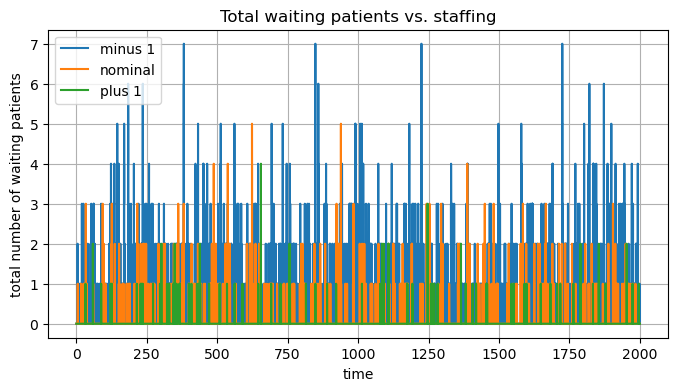

In [17]:
import matplotlib.pyplot as plt

# Fill these from part (a) and the problem statement
lambda_R = 5.0
lambda_E_ext = 2.0
mu_R, mu_I, mu_C, mu_E = 6.0, 1/3.0, 4.0, 3.0
p_R_to_IW, p_R_to_Clinic, p_R_to_ER = 0.3, 0.5, 0.1

# staffing from part (a)
nR_star, NI_star, dC_star, dE_star = 3, 500, 10, 7

T_end = 2_000.0

configs = {
    "minus 1": (nR_star-1, NI_star-1, dC_star-1, dE_star-1),
    "nominal": (nR_star,   NI_star,   dC_star,   dE_star),
    "plus 1":  (nR_star+1, NI_star+1, dC_star+1, dE_star+1),
}

plt.figure(figsize=(8,4))
for label, (nR, NI, dC, dE) in configs.items():
    t, W = simulate_hospital(lambda_R, lambda_E_ext,
                             mu_R, mu_I, mu_C, mu_E,
                             nR, NI, dC, dE,
                             p_R_to_IW, p_R_to_Clinic, p_R_to_ER,
                             T_end=T_end,
                             mode="waiting",
                             seed=123)
    plt.step(t, W, where="post", label=label)

plt.xlabel("time")
plt.ylabel("total number of waiting patients")
plt.title("Total waiting patients vs. staffing")
plt.legend()
plt.grid(True)
plt.show()

The simulation shows clear differences in system behavior under the three staffing levels. With one fewer doctor or bed than recommended, the number of waiting patients frequently spikes to high levels, indicating that the system struggles to keep up and exhibits signs of instability. Under the nominal staffing level, the number of waiting patients remains generally low, with occasional moderate spikes, suggesting that the system is stable but operates with little spare capacity. When staffing is increased by one, the number of waiting patients stays near zero for most of the simulation, showing that the system has sufficient capacity and experiences minimal congestion.

### (d)(ii):

For part (d)(ii) we reuse the discrete–event simulator from part (d)(i) and run it under the configuration from part (b):

$$
d_E = 7,\quad d_C = 10,\quad N_I = 500,
$$
with the same arrival rates, service rates, and routing probabilities as in parts (a)–(d).

We call the simulator in clinic* mode, which tracks for each completed clinic patient the total time spent in the clinic (waiting + service), and continuously accumulates the time integral of the number of busy clinic doctors.

Over a long time horizon $T_{\text{end}}$, we estimate

$$
\hat T_{\text{clinic}}
  = \frac{\text{sum of clinic sojourn times}}{\text{\# clinic departures}},
\qquad
\hat B_{\text{clinic}}
  = \frac{1}{T_{\text{end}}}\int_0^{T_{\text{end}}} B_{\text{clinic}}(t)\,dt.
$$

In [20]:
# --- configuration from part (b) ---
# same rates and routing as in d(i)
lambda_R = 5.0
lambda_E_ext = 2.0
mu_R, mu_I, mu_C, mu_E = 6.0, 1/3.0, 4.0, 3.0
p_R_to_IW, p_R_to_Clinic, p_R_to_ER = 0.3, 0.5, 0.1

# staffing from part (b)
n_R_b  = 3      
N_I_b  = 500
d_C_b  = 10
d_E_b  = 7

T_end = 2_000.0

# run simulator in "clinic" mode
avg_T_clinic_sim, avg_busy_clinic_sim = simulate_hospital(
    lambda_R, lambda_E_ext,
    mu_R, mu_I, mu_C, mu_E,
    n_R_b, N_I_b, d_C_b, d_E_b,
    p_R_to_IW, p_R_to_Clinic, p_R_to_ER,
    T_end=T_end,
    mode="clinic",
    seed=456
)

print(f"Simulated average time in clinic        : {avg_T_clinic_sim:.3f}")
print(f"Simulated average # of busy clinic docs : {avg_busy_clinic_sim:.3f}")

Simulated average time in clinic        : 0.242
Simulated average # of busy clinic docs : 0.607


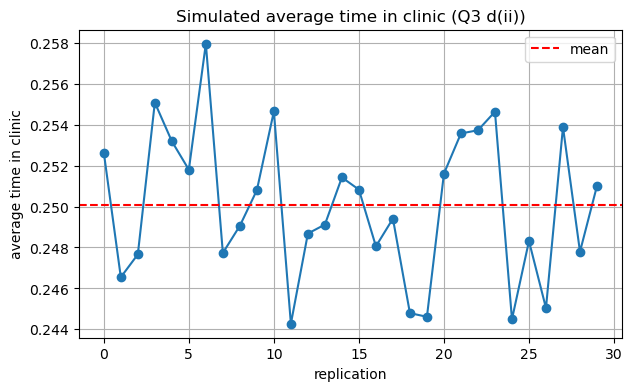

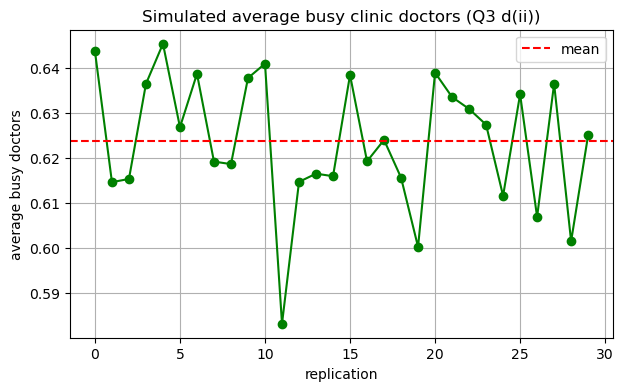

Mean clinic time = 0.25007909520654475
Mean busy clinic doctors = 0.6237359170644228


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- configuration from part (b) ---
lambda_R = 5.0
lambda_E_ext = 2.0
mu_R, mu_I, mu_C, mu_E = 6.0, 1/3.0, 4.0, 3.0
p_R_to_IW, p_R_to_Clinic, p_R_to_ER = 0.3, 0.5, 0.1

# staffing from part (b)
n_R_b  = 3
N_I_b  = 500
d_C_b  = 10
d_E_b  = 7

T_end = 2000.0
replications = 30

avg_times = []
avg_busy = []

for r in range(replications):
    T_clinic, B_clinic = simulate_hospital(
        lambda_R, lambda_E_ext,
        mu_R, mu_I, mu_C, mu_E,
        n_R_b, N_I_b, d_C_b, d_E_b,
        p_R_to_IW, p_R_to_Clinic, p_R_to_ER,
        T_end=T_end,
        mode="clinic",
        seed=1000 + r
    )
    avg_times.append(T_clinic)
    avg_busy.append(B_clinic)

# --- plot average clinic time ---
plt.figure(figsize=(7,4))
plt.plot(avg_times, marker='o')
plt.axhline(np.mean(avg_times), color='red', linestyle='--', label='mean')
plt.title("Simulated average time in clinic (Q3 d(ii))")
plt.xlabel("replication")
plt.ylabel("average time in clinic")
plt.legend()
plt.grid(True)
plt.show()

# --- plot average number of busy clinic doctors ---
plt.figure(figsize=(7,4))
plt.plot(avg_busy, marker='o', color='green')
plt.axhline(np.mean(avg_busy), color='red', linestyle='--', label='mean')
plt.title("Simulated average busy clinic doctors (Q3 d(ii))")
plt.xlabel("replication")
plt.ylabel("average busy doctors")
plt.legend()
plt.grid(True)
plt.show()

print("Mean clinic time =", np.mean(avg_times))
print("Mean busy clinic doctors =", np.mean(avg_busy))

The plots for part (d)(ii) show that, under the staffing configuration from part (b), the clinic behaves in a very stable way. The average time patients spend in the clinic in each replication stays in a narrow band around 0.25 time units, with only small random fluctuations, indicating consistently short delays. Similarly, the average number of busy clinic doctors stays close to about 0.62, meaning that on average well under one doctor is busy at any time and most of the clinic capacity is idle. Overall, the simulation suggests that with $d_C = 10$ and $d_E = 7$ the clinic is comfortably over-staffed: patients experience low waiting times, and the doctors are far from being fully utilized.